EXPERIMENT 7
TEMPORAL DIFFERENCE LEARNING USING TD(0)

10 SAMPLE DATASET RECORDS


,State,Next_State,Reward,Gamma
0,6,7,1.47,0.925
1,8,4,7.33,0.850
2,6,1,9.49,0.933
3,9,4,10.00,0.916
4,6,6,8.85,0.920
5,6,1,6.41,0.907
6,7,0,2.09,0.873
7,7,8,7.22,0.850
8,8,1,7.01,0.928
9,5,4,6.54,0.885


Total Records: 500


,min,max,mean,std
State,0.00,9.00,4.348,2.721
Next_State,0.00,9.00,4.338,2.625
Reward,-5.00,10.00,2.558,4.349
Gamma,0.85,0.99,0.921,0.036



DOWNLOAD DATASET:


...

<IPython.core.display.Javascript object>


TD(0) VS MONTE CARLO


,State,TD_0_Value,Monte_Carlo_Value,Absolute_Difference
0,0,-1.391,-1.391,0.0
1,1,-0.434,-0.434,0.0
2,2,0.629,0.629,0.0
3,3,1.810,1.810,0.0
4,4,3.122,3.122,0.0
5,5,4.580,4.580,0.0
6,6,6.200,6.200,0.0
7,7,8.000,8.000,0.0
8,8,10.000,10.000,0.0
9,9,0.000,0.000,0.0



SUMMARY RESULTS


,Metric,Result
0,Dataset Records,500.000
1,Episodes,500.000
2,States,10.000
3,Learning Rate Alpha,0.100
4,Discount Gamma,0.900
5,Average TD(0) Value,3.252
6,Average MC Value,3.252
7,Mean Absolute Difference,0.000
8,Final TD Error,0.000


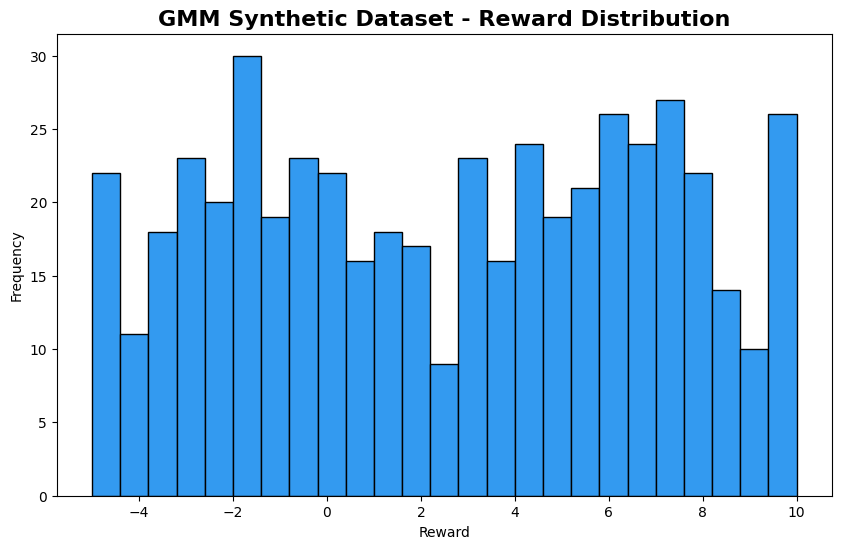

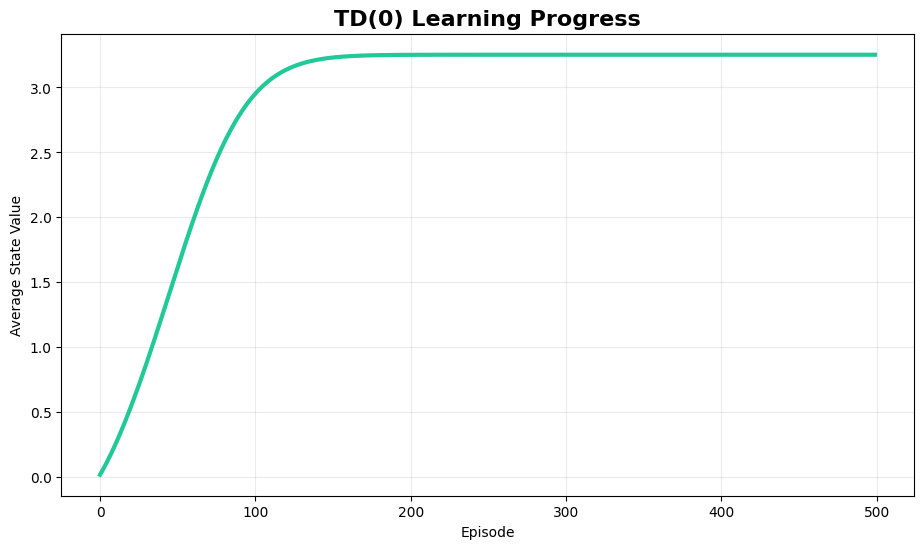

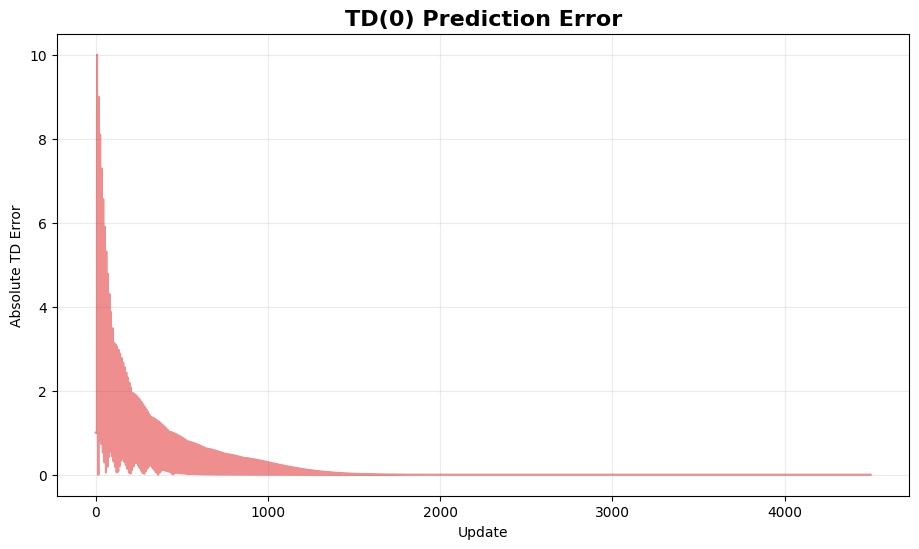

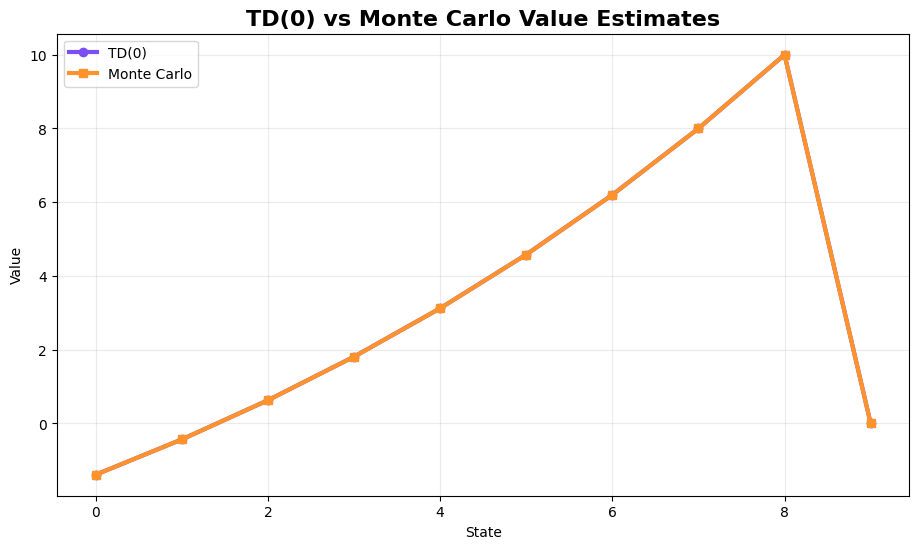

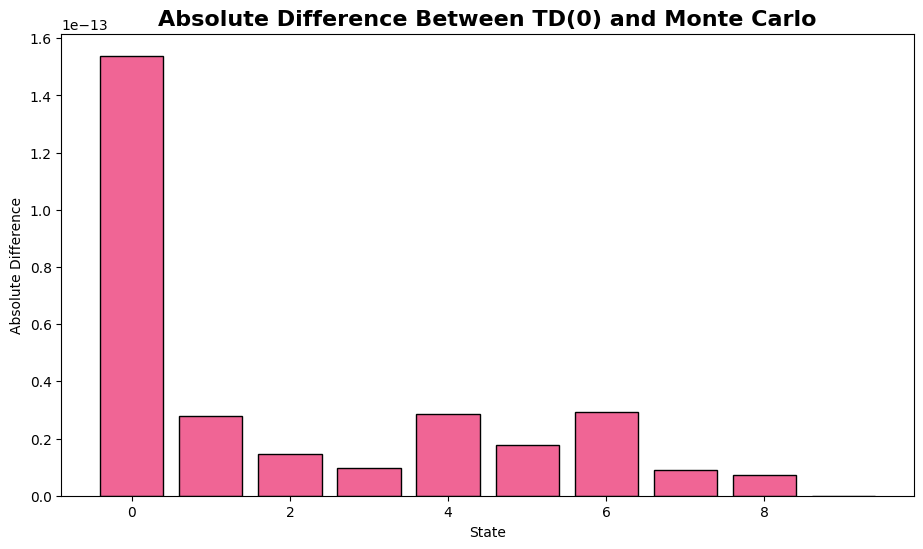


Experiment 7 completed successfully.


In [ ]:
# ==============================================================
# EXPERIMENT 7
# TEMPORAL DIFFERENCE LEARNING USING TD(0)
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from IPython.display import display, FileLink
from google.colab import files

np.random.seed(42)

print("=" * 80)
print("EXPERIMENT 7")
print("TEMPORAL DIFFERENCE LEARNING USING TD(0)")
print("=" * 80)

# ==============================================================
# 1. GMM DATASET
# ==============================================================

N = 500

base = np.column_stack([
    np.random.randint(0, 10, N),
    np.random.randint(0, 10, N),
    np.random.uniform(-5, 10, N),
    np.random.uniform(0.85, 0.99, N)
])

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(base)

generated = gmm.sample(N)[0]

dataset = pd.DataFrame(
    generated,
    columns=[
        "State",
        "Next_State",
        "Reward",
        "Gamma"
    ]
)

dataset["State"] = dataset["State"].clip(0, 9).round().astype(int)
dataset["Next_State"] = dataset["Next_State"].clip(0, 9).round().astype(int)
dataset["Reward"] = dataset["Reward"].clip(-5, 10).round(2)
dataset["Gamma"] = dataset["Gamma"].clip(0.85, 0.99).round(3)

# ==============================================================
# 2. 10 SAMPLES
# ==============================================================

print("\n10 SAMPLE DATASET RECORDS")

display(dataset.head(10))

print("Total Records:", len(dataset))

# ==============================================================
# 3. DATASET SUMMARY
# ==============================================================

display(
    dataset.describe().T[
        ["min", "max", "mean", "std"]
    ].round(3)
)

# ==============================================================
# 4. DOWNLOAD
# ==============================================================

filename = "Experiment_7_TD0_GMM_Dataset.csv"

dataset.to_csv(
    filename,
    index=False
)

print("\nDOWNLOAD DATASET:")

display(FileLink(filename))

files.download(filename)

# ==============================================================
# 5. PARAMETERS
# ==============================================================

N_STATES = 10
EPISODES = 500

ALPHA = 0.10
GAMMA = 0.90

# ==============================================================
# 6. EPISODE GENERATOR
# ==============================================================

def generate_episode():

    state = 0
    episode = []

    while state != 9:

        next_state = min(
            state + 1,
            9
        )

        reward = (
            10
            if next_state == 9
            else -1
        )

        episode.append(
            (
                state,
                reward,
                next_state
            )
        )

        state = next_state

    return episode

# ==============================================================
# 7. TD(0)
# ==============================================================

V_td = np.zeros(
    N_STATES
)

td_history = []
td_errors = []

for episode in range(EPISODES):

    ep = generate_episode()

    for state, reward, next_state in ep:

        target = (
            reward +
            GAMMA *
            V_td[next_state]
        )

        error = (
            target -
            V_td[state]
        )

        V_td[state] += (
            ALPHA * error
        )

        td_errors.append(
            abs(error)
        )

    td_history.append(
        np.mean(V_td)
    )

# ==============================================================
# 8. MONTE CARLO COMPARISON
# ==============================================================

V_mc = np.zeros(
    N_STATES
)

returns_sum = np.zeros(
    N_STATES
)

returns_count = np.zeros(
    N_STATES
)

for _ in range(EPISODES):

    ep = generate_episode()

    G = 0
    visited = set()

    for state, reward, next_state in reversed(ep):

        G = reward + GAMMA * G

        if state not in visited:

            returns_sum[state] += G
            returns_count[state] += 1

            V_mc[state] = (
                returns_sum[state]
                /
                returns_count[state]
            )

            visited.add(state)

# ==============================================================
# 9. COMPARISON TABLE
# ==============================================================

comparison = pd.DataFrame({
    "State": range(N_STATES),
    "TD_0_Value": V_td,
    "Monte_Carlo_Value": V_mc,
    "Absolute_Difference": np.abs(V_td - V_mc)
}).round(3)

print("\nTD(0) VS MONTE CARLO")

display(comparison)

# ==============================================================
# 10. SUMMARY
# ==============================================================

summary = pd.DataFrame({
    "Metric": [
        "Dataset Records",
        "Episodes",
        "States",
        "Learning Rate Alpha",
        "Discount Gamma",
        "Average TD(0) Value",
        "Average MC Value",
        "Mean Absolute Difference",
        "Final TD Error"
    ],

    "Result": [
        len(dataset),
        EPISODES,
        N_STATES,
        ALPHA,
        GAMMA,
        round(np.mean(V_td), 3),
        round(np.mean(V_mc), 3),
        round(np.mean(np.abs(V_td - V_mc)), 3),
        round(td_errors[-1], 4)
    ]
})

print("\nSUMMARY RESULTS")

display(summary)

# ==============================================================
# 11. VISUALIZATION 1
# REWARD DISTRIBUTION
# ==============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    dataset["Reward"],
    bins=25,
    color="#339af0",
    edgecolor="black"
)

plt.title(
    "GMM Synthetic Dataset - Reward Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Reward")
plt.ylabel("Frequency")

plt.show()

# ==============================================================
# 12. VISUALIZATION 2
# TD LEARNING CURVE
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    td_history,
    color="#20c997",
    linewidth=3
)

plt.title(
    "TD(0) Learning Progress",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average State Value")

plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 13. VISUALIZATION 3
# TD ERROR
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    td_errors,
    color="#e03131",
    alpha=0.55
)

plt.title(
    "TD(0) Prediction Error",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Update")
plt.ylabel("Absolute TD Error")

plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 14. VISUALIZATION 4
# TD VS MC
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    range(N_STATES),
    V_td,
    marker="o",
    linewidth=3,
    color="#7950f2",
    label="TD(0)"
)

plt.plot(
    range(N_STATES),
    V_mc,
    marker="s",
    linewidth=3,
    color="#ff922b",
    label="Monte Carlo"
)

plt.title(
    "TD(0) vs Monte Carlo Value Estimates",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Value")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 15. VISUALIZATION 5
# ABSOLUTE DIFFERENCE
# ==============================================================

plt.figure(figsize=(11, 6))

plt.bar(
    range(N_STATES),
    np.abs(V_td - V_mc),
    color="#f06595",
    edgecolor="black"
)

plt.title(
    "Absolute Difference Between TD(0) and Monte Carlo",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Absolute Difference")

plt.show()

print("\nExperiment 7 completed successfully.")